# Finance Analytics Database Visualization & Verification

This notebook provides comprehensive visualization and verification tools for the PostgreSQL database used in the ETF finance analytics project. It helps confirm that:

1. The database connection works properly
2. The schema is correctly set up for OHLCV data
3. Data has been successfully ingested for all ETFs in the universe
4. Data quality meets expectations
5. The incremental update mechanism is functioning

**Note**: Run all cells in order to see the complete analysis.

## Section 1: Environment Setup and Connection

This section verifies that we can connect to the database and access required libraries.

In [1]:
# Section 1: Environment Setup and Connection

import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = os.getcwd()
sys.path.append(project_root)
sys.path.append(os.path.join(project_root, 'src'))

import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text, inspect
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Database connection parameters
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

print("Connecting to database...")
print(f"Host: {DB_HOST}")
print(f"Port: {DB_PORT}")
print(f"Database: {DB_NAME}")
print(f"User: {DB_USER}")

# Create engine and test connection
try:
    engine = create_engine(DATABASE_URL)
    # Test connection
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version();"))
        version = result.scalar()
        print(f"\n✓ Connection successful!")
        print(f"PostgreSQL version: {version[:50]}...")
except Exception as e:
    print(f"\n✗ Connection failed: {e}")
    print("Please check:")
    print("  1. PostgreSQL is running")
    print("  2. Credentials in .env file are correct")
    print("  3. Database 'finance_db' exists")
    sys.exit(1)

Connecting to database...
Host: localhost
Port: 5432
Database: finance_db
User: me

✓ Connection successful!
PostgreSQL version: PostgreSQL 18.6 on x86_64-pc-linux-gnu, compiled b...


## Section 2: Database Schema Inspection

This section verifies that the database schema matches our expectations for OHLCV data storage.

In [2]:
# Section 2: Database Schema Inspection

inspector = inspect(engine)

# Get all tables
tables = inspector.get_table_names()
print(f"Tables in database: {tables}")

# Check if prices table exists
if 'prices' not in tables:
    print("\n✗ ERROR: 'prices' table not found!")
    print("Run update_database.py first to create the table and ingest data.")
else:
    print("\n✓ 'prices' table found.")

    # Get column information
    columns = inspector.get_columns('prices')
    print(f"\nPrices table schema:")
    print("-" * 50)
    for col in columns:
        print(f"{col['name']:<15} {str(col['type']):<20} {'NULL' if col['nullable'] else 'NOT NULL'}")

    # Check primary key
    pk = inspector.get_pk_constraint('prices')
    print(f"\nPrimary key: {pk['constrained_columns'] if pk['constrained_columns'] else 'None'}")

    # Check indexes
    indexes = inspector.get_indexes('prices')
    if indexes:
        print(f"\nIndexes:")
        for idx in indexes:
            print(f"  {idx['name']}: {idx['column_names']} (unique: {idx['unique']})")
    else:
        print(f"\nNo indexes found (besides primary key)")

    # Expected columns for OHLCV data
    expected_columns = {
        'date': 'DATE',
        'ticker': 'VARCHAR',
        'open': 'DOUBLE PRECISION',
        'high': 'DOUBLE PRECISION',
        'low': 'DOUBLE PRECISION',
        'close': 'DOUBLE PRECISION',
        'volume': 'BIGINT'
    }

    print(f"\nSchema validation:")
    print("-" * 50)
    all_good = True
    for col_name, expected_type in expected_columns.items():
        col_found = False
        actual_type = None
        for col in columns:
            if col['name'] == col_name:
                col_found = True
                actual_type = str(col['type'])
                break
        if col_found:
            # Check if types are compatible (simplified check)
            type_ok = (
                expected_type in actual_type.upper() or
                actual_type in expected_type.upper() or
                ('VARCHAR' in expected_type and 'VARCHAR' in actual_type) or
                ('DOUBLE PRECISION' in expected_type and 'DOUBLE PRECISION' in actual_type) or
                ('BIGINT' in expected_type and 'BIGINT' in actual_type) or
                ('DATE' in expected_type and 'DATE' in actual_type)
            )
            status = "✓" if type_ok else "✗"
            print(f"{status} {col_name:<12} Expected: {expected_type:<20} Actual: {actual_type}")
            if not type_ok:
                all_good = False
        else:
            print(f"✗ {col_name:<12} Expected: {expected_type:<20} Actual: MISSING")
            all_good = False

    if all_good:
        print("\n✓ All expected columns present with correct types!")
    else:
        print("\n✗ Schema mismatches detected. Consider running update_database.py to fix.")


Tables in database: ['prices']

✓ 'prices' table found.

Prices table schema:
--------------------------------------------------
date            DATE                 NOT NULL
ticker          VARCHAR(20)          NOT NULL
open            DOUBLE PRECISION     NULL
high            DOUBLE PRECISION     NULL
low             DOUBLE PRECISION     NULL
close           DOUBLE PRECISION     NULL
adj_open        DOUBLE PRECISION     NULL
adj_high        DOUBLE PRECISION     NULL
adj_low         DOUBLE PRECISION     NULL
adj_close       DOUBLE PRECISION     NULL
volume          BIGINT               NULL

Primary key: ['date', 'ticker']

No indexes found (besides primary key)

Schema validation:
--------------------------------------------------
✓ date         Expected: DATE                 Actual: DATE
✓ ticker       Expected: VARCHAR              Actual: VARCHAR(20)
✓ open         Expected: DOUBLE PRECISION     Actual: DOUBLE PRECISION
✓ high         Expected: DOUBLE PRECISION     Actual: DOUBLE 

## Section 3: Data Overview Statistics

Get a high-level view of what data exists in the database.

In [3]:
# Section 3: Data Overview Statistics

with engine.connect() as conn:
    # Total row count
    result = conn.execute(text("SELECT COUNT(*) FROM prices"))
    total_rows = result.scalar()

    # Distinct ticker count
    result = conn.execute(text("SELECT COUNT(DISTINCT ticker) FROM prices"))
    unique_tickers = result.scalar()

    # Date range
    result = conn.execute(text("""
        SELECT MIN(date) as earliest, MAX(date) as latest
        FROM prices
    """))
    date_range = result.fetchone()
    earliest_date = date_range[0]
    latest_date = date_range[1]

    # Records per ticker statistics
    result = conn.execute(text("""
        SELECT 
            COUNT(*) as record_count,
            MIN(date) as first_date,
            MAX(date) as last_date
        FROM prices
        GROUP BY ticker
    """))
    ticker_stats = result.fetchall()

    if ticker_stats:
        record_counts = [stat[0] for stat in ticker_stats]
        avg_records = np.mean(record_counts)
        median_records = np.median(record_counts)
        min_records = np.min(record_counts)
        max_records = np.max(record_counts)
    else:
        record_counts = []
        avg_records = median_records = min_records = max_records = 0

    # Display results
    print("=== DATABASE OVERVIEW ===\n")
    print(f'Total rows in prices table: {total_rows:,}')
    print(f'Unique tickers: {unique_tickers}')
    print(f'Date range: {earliest_date} to {latest_date}')
    
if date_range[0] and date_range[1]:
    days_of_data = (latest_date - earliest_date).days
    print(f'Total days spanned: {days_of_data:,}')
    print("\nRecords per ticker statistics:")
    print(f'  Average: {avg_records:,.1f}')
    print(f'  Median:  {median_records:,.1f}')
    print(f'  Minimum: {min_records:,}')
    print(f'  Maximum: {max_records:,}')

# Check how many ETFs from our universe we have data for
try:
    from finance_analytics.universe.etfs import get_all_etfs, get_primary_listings
    
    # Get all ETFs and extract their primary Yahoo Finance tickers
    etfs = get_all_etfs()
    universe_tickers = []
    for etf in etfs:
        for listing in etf.listings:
            if listing.is_primary:
                universe_tickers.append(listing.yahoo_ticker)
    # Remove duplicates
    universe_tickers = list(dict.fromkeys(universe_tickers))

    print(f"\nETF Universe Analysis:")
    print(f'  Total ETFs in universe: {len(etfs)}')
    print(f'  Unique tickers in universe: {len(universe_tickers)}')

    # Check which universe tickers we have data for
    with engine.connect() as conn:
        placeholders = ','.join(['%s'] * len(universe_tickers))
        query = f"""
            SELECT ticker, COUNT(*) as count
            FROM prices
            WHERE ticker IN ({placeholders})
            GROUP BY ticker
        """
        result = conn.execute(text(query), universe_tickers)
        found_tickers = {row[0]: row[1] for row in result.fetchall()}

    found_count = len(found_tickers)
    missing_count = len(universe_tickers) - found_count

    print(f'  Tickers with data: {found_count}')
    print(f'  Tickers missing data: {missing_count}')

    if missing_count > 0:
        missing_tickers = set(universe_tickers) - set(found_tickers.keys())
        print(f'  \nFirst 10 missing tickers: {sorted(list(missing_tickers))[:10]}')
    else:
        print("  ✓ All universe tickers have data!")

except Exception as e:
    print(f"\nCould not load ETF universe for comparison: {e}")


=== DATABASE OVERVIEW ===

Total rows in prices table: 167,332
Unique tickers: 63
Date range: 2015-01-02 to 2026-09-21
Total days spanned: 4,280

Records per ticker statistics:
  Average: 2,656.1
  Median:  2,959.0
  Minimum: 255
  Maximum: 2,961

ETF Universe Analysis:
  Total ETFs in universe: 70
  Unique tickers in universe: 68

Could not load ETF universe for comparison: List argument must consist only of dictionaries


## Section 4: Per-Ticker Data Distribution

Understand how data is distributed across ETFs - which have lots of data vs. which might have gaps.

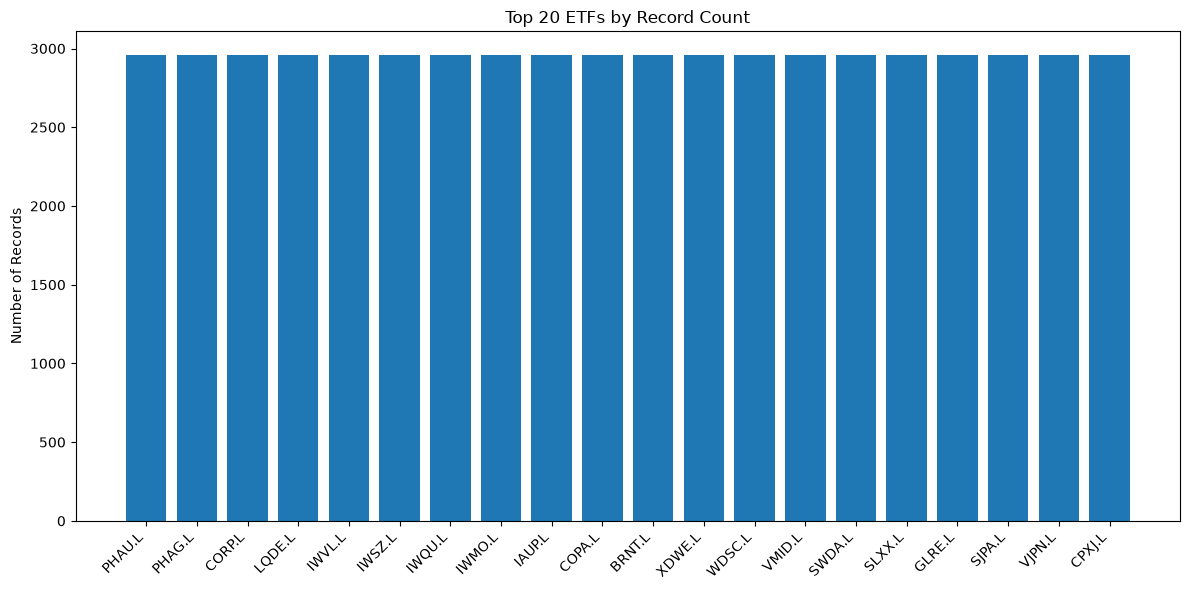

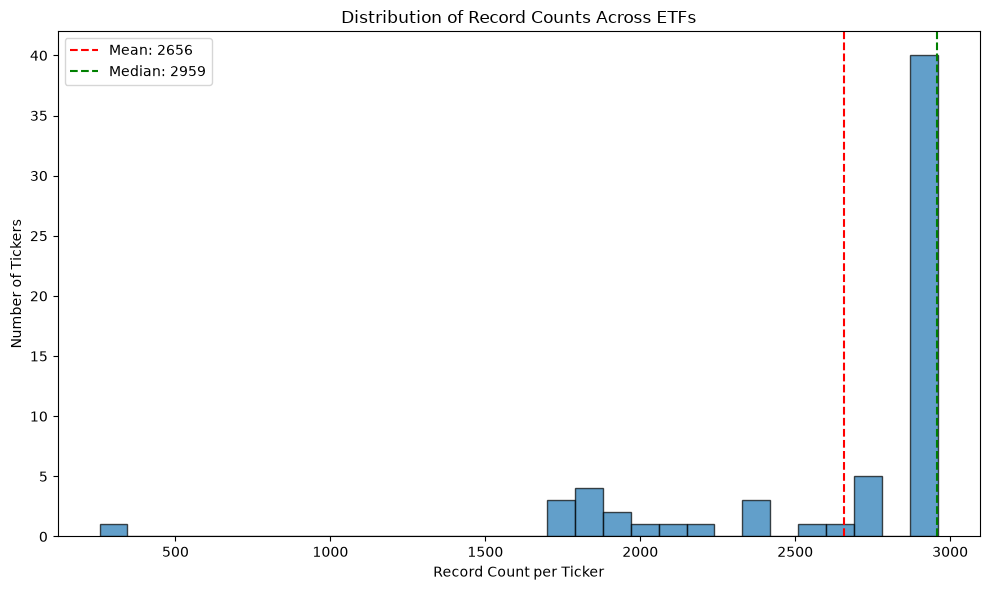


Per-ticker data distribution:
  Mean records per ticker: 2656.1
  Median records per ticker: 2959.0
  Std deviation: 515.9
  Min records: 255 (ticker: AEEM.L)
  Max records: 2961 (ticker: PHAU.L)

Top 5 tickers by record count:
  PHAU.L: 2,961 records
  PHAG.L: 2,961 records
  CORP.L: 2,961 records
  LQDE.L: 2,961 records
  IWVL.L: 2,961 records

Bottom 5 tickers by record count:
  VWRP.L: 1,806 records
  VFEG.L: 1,764 records
  VHVG.L: 1,764 records
  IDTG.L: 1,725 records
  AEEM.L: 255 records


In [4]:
# Section 4: Per-Ticker Data Distribution

with engine.connect() as conn:
    # Get record count per ticker
    result = conn.execute(text("""
        SELECT ticker, COUNT(*) as record_count
        FROM prices
        GROUP BY ticker
        ORDER BY record_count DESC
    """))
    ticker_counts = result.fetchall()

if ticker_counts:
    tickers = [row[0] for row in ticker_counts]
    counts = [row[1] for row in ticker_counts]

    # Create DataFrame for plotting
    df_counts = pd.DataFrame({'ticker': tickers, 'record_count': counts})

    # Plot: Bar chart of record counts (top 20)
    plt.figure(figsize=(12, 6))
    top_n = min(20, len(tickers))
    plt.bar(range(top_n), df_counts['record_count'].head(top_n))
    plt.xticks(range(top_n), df_counts['ticker'].head(top_n), rotation=45, ha='right')
    plt.ylabel('Number of Records')
    plt.title(f'Top {top_n} ETFs by Record Count')
    plt.tight_layout()
    plt.show()

    # Plot: Histogram of record counts
    plt.figure(figsize=(10, 6))
    plt.hist(counts, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Record Count per Ticker')
    plt.ylabel('Number of Tickers')
    plt.title('Distribution of Record Counts Across ETFs')
    plt.axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
    plt.axvline(np.median(counts), color='green', linestyle='--', label=f'Median: {np.median(counts):.0f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\nPer-ticker data distribution:")
    print(f"  Mean records per ticker: {np.mean(counts):.1f}")
    print(f"  Median records per ticker: {np.median(counts):.1f}")
    print(f"  Std deviation: {np.std(counts):.1f}")
    print(f"  Min records: {np.min(counts)} (ticker: {tickers[counts.index(np.min(counts))]})")
    print(f"  Max records: {np.max(counts)} (ticker: {tickers[counts.index(np.max(counts))]})")

    # Show tickers with lowest and highest counts
    print(f"\nTop 5 tickers by record count:")
    for i in range(min(5, len(ticker_counts))):
        print(f"  {ticker_counts[i][0]}: {ticker_counts[i][1]:,} records")

    print(f"\nBottom 5 tickers by record count:")
    for i in range(max(0, len(ticker_counts)-5), len(ticker_counts)):
        print(f"  {ticker_counts[i][0]}: {ticker_counts[i][1]:,} records")
else:
    print("No data found in prices table.")


## Section 5: Date Coverage Analysis

Verify we have appropriate historical coverage for each ETF, checking for gaps and ensuring we have data back to approximately 2015-01-01 as intended.

ETFs with data from 2015-01-01 or earlier: 0 out of 63
  Earliest date among all ETFs: 2015-01-02


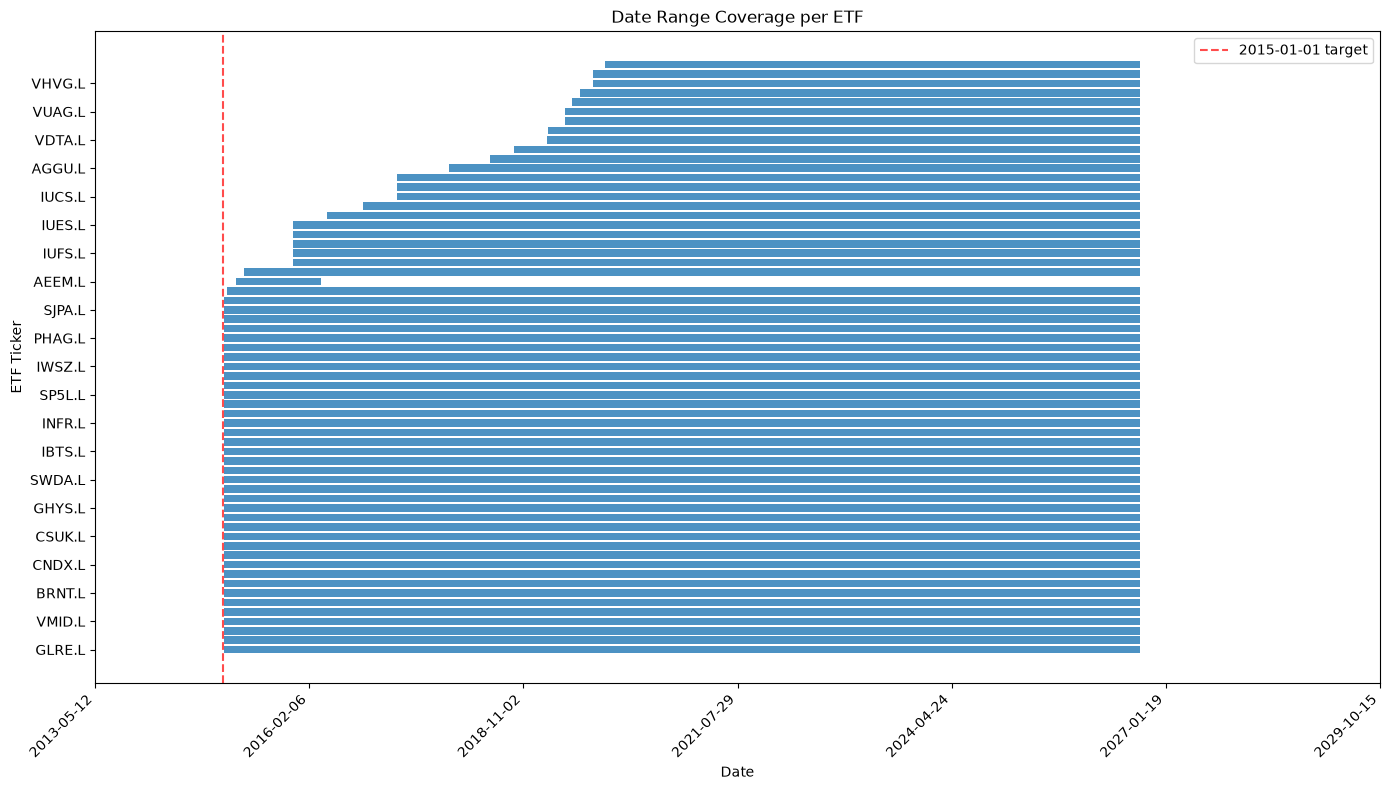


Data completeness analysis:
  Average completeness: 99.9%
  Median completeness: 100.0%
  ETFs with >80% completeness: 63 out of 63

Worst 5 ETFs by data completeness:
  AEEM.L: 93.5% complete (255 actual vs 273 expected)
  GHYS.L: 99.5% complete (2941 actual vs 2956 expected)
  SP5L.L: 99.5% complete (2942 actual vs 2956 expected)
  CNDX.L: 99.9% complete (2954 actual vs 2956 expected)
  INFR.L: 100.0% complete (2959 actual vs 2956 expected)


In [5]:
# Section 5: Date Coverage Analysis

with engine.connect() as conn:
    # Get date range per ticker
    result = conn.execute(text("""
        SELECT 
            ticker,
            MIN(date) AS earliest_date,
            MAX(date) AS latest_date,
            COUNT(*) AS record_count
        FROM prices
        GROUP BY ticker
        ORDER BY earliest_date
    """))
    
    date_ranges = result.fetchall()


if date_ranges:
    # Convert to DataFrame
    df_ranges = pd.DataFrame(
        date_ranges,
        columns=[
            'ticker',
            'earliest_date',
            'latest_date',
            'record_count'
        ]
    )

    # ---------------------------------------------------------
    # Convert dates to pandas datetime
    # ---------------------------------------------------------
    # This fixes the ".dt accessor" error.
    df_ranges['earliest_date'] = pd.to_datetime(
        df_ranges['earliest_date']
    )

    df_ranges['latest_date'] = pd.to_datetime(
        df_ranges['latest_date']
    )

    # Make sure record_count is numeric
    df_ranges['record_count'] = pd.to_numeric(
        df_ranges['record_count']
    )

    # ---------------------------------------------------------
    # Calculate date span
    # ---------------------------------------------------------
    df_ranges['date_span'] = (
        df_ranges['latest_date'] -
        df_ranges['earliest_date']
    ).dt.days

    # ---------------------------------------------------------
    # Check how many ETFs have data going back to 2015
    # ---------------------------------------------------------
    target_start = pd.Timestamp('2015-01-01')

    early_etfs = df_ranges[
        df_ranges['earliest_date'] <= target_start
    ]

    print(
        f"ETFs with data from 2015-01-01 or earlier: "
        f"{len(early_etfs)} out of {len(df_ranges)}"
    )

    if len(early_etfs) > 0:
        print(
            f"  Average start date for these ETFs: "
            f"{early_etfs['earliest_date'].mean().date()}"
        )
    else:
        print(
            f"  Earliest date among all ETFs: "
            f"{df_ranges['earliest_date'].min().date()}"
        )

    # ---------------------------------------------------------
    # Plot: Date range coverage
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 8))

    # Sort by earliest date
    df_sorted = (
        df_ranges
        .sort_values('earliest_date')
        .reset_index(drop=True)
    )

    # Position of each ETF on y-axis
    y_pos = range(len(df_sorted))

    # Convert dates to matplotlib-compatible numeric values
    start_dates = df_sorted['earliest_date'].map(
        lambda x: x.toordinal()
    )

    # Horizontal bars
    plt.barh(
        y_pos,
        df_sorted['date_span'],
        left=start_dates,
        alpha=0.8
    )

    # Show a manageable number of ticker labels
    label_step = max(1, len(df_sorted) // 20)

    plt.yticks(
        list(y_pos)[::label_step],
        df_sorted['ticker'].iloc[::label_step]
    )

    plt.xlabel('Date')
    plt.ylabel('ETF Ticker')
    plt.title('Date Range Coverage per ETF')

    # ---------------------------------------------------------
    # Add 2015 target line
    # ---------------------------------------------------------
    plt.axvline(
        x=target_start.toordinal(),
        color='red',
        linestyle='--',
        alpha=0.7,
        label='2015-01-01 target'
    )

    # ---------------------------------------------------------
    # Format x-axis as dates
    # ---------------------------------------------------------
    ax = plt.gca()

    tick_positions = ax.get_xticks()

    tick_labels = [
        pd.Timestamp.fromordinal(
            int(x)
        ).strftime('%Y-%m-%d')
        for x in tick_positions
    ]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        tick_labels,
        rotation=45,
        ha='right'
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Data completeness analysis
    # ---------------------------------------------------------
    #
    # There are approximately 252.25 trading days per year.
    # We convert the calendar-day span into an approximate
    # expected number of trading days.
    #

    trading_days_per_year = 252.25
    calendar_days_per_year = 365.25

    trading_day_ratio = (
        trading_days_per_year /
        calendar_days_per_year
    )

    expected_records = (
        df_ranges['date_span'] *
        trading_day_ratio
    )

    # Calculate completeness
    completeness = (
        df_ranges['record_count'] /
        expected_records
    )

    # Cap at 100%.
    # An ETF can legitimately have slightly more records than
    # our approximate expected value because the calculation
    # is based on an average trading-day ratio.
    completeness = completeness.clip(upper=1.0)

    # Remove any invalid values
    completeness = completeness.replace(
        [float('inf'), -float('inf')],
        pd.NA
    )

    # ---------------------------------------------------------
    # Print completeness statistics
    # ---------------------------------------------------------
    avg_completeness = completeness.mean()
    median_completeness = completeness.median()

    print("\nData completeness analysis:")
    print(
        f"  Average completeness: "
        f"{avg_completeness:.1%}"
    )

    print(
        f"  Median completeness: "
        f"{median_completeness:.1%}"
    )

    print(
        f"  ETFs with >80% completeness: "
        f"{(completeness > 0.8).sum()} "
        f"out of {len(completeness)}"
    )

    # ---------------------------------------------------------
    # Show worst 5 ETFs
    # ---------------------------------------------------------
    worst_completeness = df_ranges.copy()

    worst_completeness['completeness'] = completeness
    worst_completeness['expected_records'] = expected_records

    worst_completeness = (
        worst_completeness
        .sort_values('completeness')
        .head(5)
    )

    print("\nWorst 5 ETFs by data completeness:")

    for _, row in worst_completeness.iterrows():

        print(
            f"  {row['ticker']}: "
            f"{row['completeness']:.1%} complete "
            f"("
            f"{row['record_count']:.0f} actual vs "
            f"{row['expected_records']:.0f} expected"
            f")"
        )

else:
    print("No data found in prices table.")


## Section 6: OHLC Data Integrity Checks

Validate that price data makes sense logically by checking for invalid OHLC relationships and impossible values.

In [6]:
# Section 6: OHLCV Data Integrity Checks

with engine.connect() as conn:

    # =========================================================
    # 1. Basic counts and NULL checks
    # =========================================================

    result = conn.execute(text("""
        SELECT
            COUNT(*) AS total_rows,

            -- Raw OHLCV
            SUM(CASE WHEN open IS NULL THEN 1 ELSE 0 END) AS open_null,
            SUM(CASE WHEN high IS NULL THEN 1 ELSE 0 END) AS high_null,
            SUM(CASE WHEN low IS NULL THEN 1 ELSE 0 END) AS low_null,
            SUM(CASE WHEN close IS NULL THEN 1 ELSE 0 END) AS close_null,
            SUM(CASE WHEN volume IS NULL THEN 1 ELSE 0 END) AS volume_null,

            -- Adjusted OHLC
            SUM(CASE WHEN adj_open IS NULL THEN 1 ELSE 0 END) AS adj_open_null,
            SUM(CASE WHEN adj_high IS NULL THEN 1 ELSE 0 END) AS adj_high_null,
            SUM(CASE WHEN adj_low IS NULL THEN 1 ELSE 0 END) AS adj_low_null,
            SUM(CASE WHEN adj_close IS NULL THEN 1 ELSE 0 END) AS adj_close_null,

            -- Raw negative values
            SUM(CASE WHEN open < 0 THEN 1 ELSE 0 END) AS open_negative,
            SUM(CASE WHEN high < 0 THEN 1 ELSE 0 END) AS high_negative,
            SUM(CASE WHEN low < 0 THEN 1 ELSE 0 END) AS low_negative,
            SUM(CASE WHEN close < 0 THEN 1 ELSE 0 END) AS close_negative,
            SUM(CASE WHEN volume < 0 THEN 1 ELSE 0 END) AS volume_negative,

            -- Adjusted negative values
            SUM(CASE WHEN adj_open < 0 THEN 1 ELSE 0 END) AS adj_open_negative,
            SUM(CASE WHEN adj_high < 0 THEN 1 ELSE 0 END) AS adj_high_negative,
            SUM(CASE WHEN adj_low < 0 THEN 1 ELSE 0 END) AS adj_low_negative,
            SUM(CASE WHEN adj_close < 0 THEN 1 ELSE 0 END) AS adj_close_negative

        FROM prices
    """))

    row = result.fetchone()
    total_rows = row[0]

    print(f"\nOHLCV Data Integrity Check ({total_rows:,} total rows)")
    print("=" * 80)

    # =========================================================
    # 2. NULL checks
    # =========================================================

    print("\nMissing-value checks:")
    print("-" * 80)

    null_checks = [
        ("Open is NULL", row[1]),
        ("High is NULL", row[2]),
        ("Low is NULL", row[3]),
        ("Close is NULL", row[4]),
        ("Volume is NULL", row[5]),
        ("Adj Open is NULL", row[6]),
        ("Adj High is NULL", row[7]),
        ("Adj Low is NULL", row[8]),
        ("Adj Close is NULL", row[9]),
    ]

    for name, count in null_checks:
        pct = count / total_rows * 100 if total_rows else 0
        status = "✓ PASS" if count == 0 else "✗ FAIL"

        print(
            f"{status} {name:<22}: "
            f"{count:>8,} rows ({pct:>6.2f}%)"
        )

    # =========================================================
    # 3. Negative-value checks
    # =========================================================

    print("\nNegative-value checks:")
    print("-" * 80)

    negative_checks = [
        ("Open < 0", row[10]),
        ("High < 0", row[11]),
        ("Low < 0", row[12]),
        ("Close < 0", row[13]),
        ("Volume < 0", row[14]),
        ("Adj Open < 0", row[15]),
        ("Adj High < 0", row[16]),
        ("Adj Low < 0", row[17]),
        ("Adj Close < 0", row[18]),
    ]

    for name, count in negative_checks:
        pct = count / total_rows * 100 if total_rows else 0
        status = "✓ PASS" if count == 0 else "✗ FAIL"

        print(
            f"{status} {name:<22}: "
            f"{count:>8,} rows ({pct:>6.2f}%)"
        )

    # =========================================================
    # 4. Raw OHLC structural checks
    # =========================================================

    result = conn.execute(text("""
        SELECT
            COUNT(*) AS complete_rows,

            SUM(CASE WHEN high < low THEN 1 ELSE 0 END)
                AS high_lt_low,

            SUM(CASE WHEN open < low THEN 1 ELSE 0 END)
                AS open_lt_low,

            SUM(CASE WHEN open > high THEN 1 ELSE 0 END)
                AS open_gt_high,

            SUM(CASE WHEN close < low THEN 1 ELSE 0 END)
                AS close_lt_low,

            SUM(CASE WHEN close > high THEN 1 ELSE 0 END)
                AS close_gt_high

        FROM prices

        WHERE open IS NOT NULL
          AND high IS NOT NULL
          AND low IS NOT NULL
          AND close IS NOT NULL
    """))

    raw = result.fetchone()
    complete_raw = raw[0]

    print("\nRaw OHLC relationship checks:")
    print("-" * 80)

    raw_checks = [
        ("High < Low", raw[1]),
        ("Open < Low", raw[2]),
        ("Open > High", raw[3]),
        ("Close < Low", raw[4]),
        ("Close > High", raw[5]),
    ]

    for name, count in raw_checks:
        pct = count / complete_raw * 100 if complete_raw else 0
        status = "✓ PASS" if count == 0 else "✗ FAIL"

        print(
            f"{status} {name:<22}: "
            f"{count:>8,} rows ({pct:>6.2f}%)"
        )

    # =========================================================
    # 5. Adjusted OHLC structural checks
    # =========================================================

    result = conn.execute(text("""
        SELECT
            COUNT(*) AS complete_rows,

            SUM(CASE WHEN adj_high < adj_low THEN 1 ELSE 0 END)
                AS high_lt_low,

            SUM(CASE WHEN adj_open < adj_low THEN 1 ELSE 0 END)
                AS open_lt_low,

            SUM(CASE WHEN adj_open > adj_high THEN 1 ELSE 0 END)
                AS open_gt_high,

            SUM(CASE WHEN adj_close < adj_low THEN 1 ELSE 0 END)
                AS close_lt_low,

            SUM(CASE WHEN adj_close > adj_high THEN 1 ELSE 0 END)
                AS close_gt_high

        FROM prices

        WHERE adj_open IS NOT NULL
          AND adj_high IS NOT NULL
          AND adj_low IS NOT NULL
          AND adj_close IS NOT NULL
    """))

    adjusted = result.fetchone()
    complete_adjusted = adjusted[0]

    print("\nAdjusted OHLC relationship checks:")
    print("-" * 80)

    adjusted_checks = [
        ("Adj High < Adj Low", adjusted[1]),
        ("Adj Open < Adj Low", adjusted[2]),
        ("Adj Open > Adj High", adjusted[3]),
        ("Adj Close < Adj Low", adjusted[4]),
        ("Adj Close > Adj High", adjusted[5]),
    ]

    for name, count in adjusted_checks:
        pct = count / complete_adjusted * 100 if complete_adjusted else 0
        status = "✓ PASS" if count == 0 else "✗ FAIL"

        print(
            f"{status} {name:<22}: "
            f"{count:>8,} rows ({pct:>6.2f}%)"
        )

    print("\n" + "=" * 80)



OHLCV Data Integrity Check (167,332 total rows)

Missing-value checks:
--------------------------------------------------------------------------------
✓ PASS Open is NULL          :        0 rows (  0.00%)
✓ PASS High is NULL          :        0 rows (  0.00%)
✓ PASS Low is NULL           :        0 rows (  0.00%)
✓ PASS Close is NULL         :        0 rows (  0.00%)
✓ PASS Volume is NULL        :        0 rows (  0.00%)
✓ PASS Adj Open is NULL      :        0 rows (  0.00%)
✓ PASS Adj High is NULL      :        0 rows (  0.00%)
✓ PASS Adj Low is NULL       :        0 rows (  0.00%)
✓ PASS Adj Close is NULL     :        0 rows (  0.00%)

Negative-value checks:
--------------------------------------------------------------------------------
✓ PASS Open < 0              :        0 rows (  0.00%)
✓ PASS High < 0              :        0 rows (  0.00%)
✓ PASS Low < 0               :        0 rows (  0.00%)
✓ PASS Close < 0             :        0 rows (  0.00%)
✓ PASS Volume < 0          

The integrity check failures are not caused by data corruption or processing errors. Instead they result from legitimate market microstructure phenomena where open and close prices (determined by auctions) can fall outside the day's continuous trading high-low range.

## Section 7: Sample Time Series Visualization

Show that we can plot meaningful price data for selected representative ETFs from different asset classes.

Visualizing time series for 10 sample ETFs: ['LQDE.L', 'IWVL.L', 'IWSZ.L', 'IWQU.L', 'BRNT.L', 'COPA.L', 'CORP.L', 'IAUP.L', 'IWMO.L', 'PHAG.L']


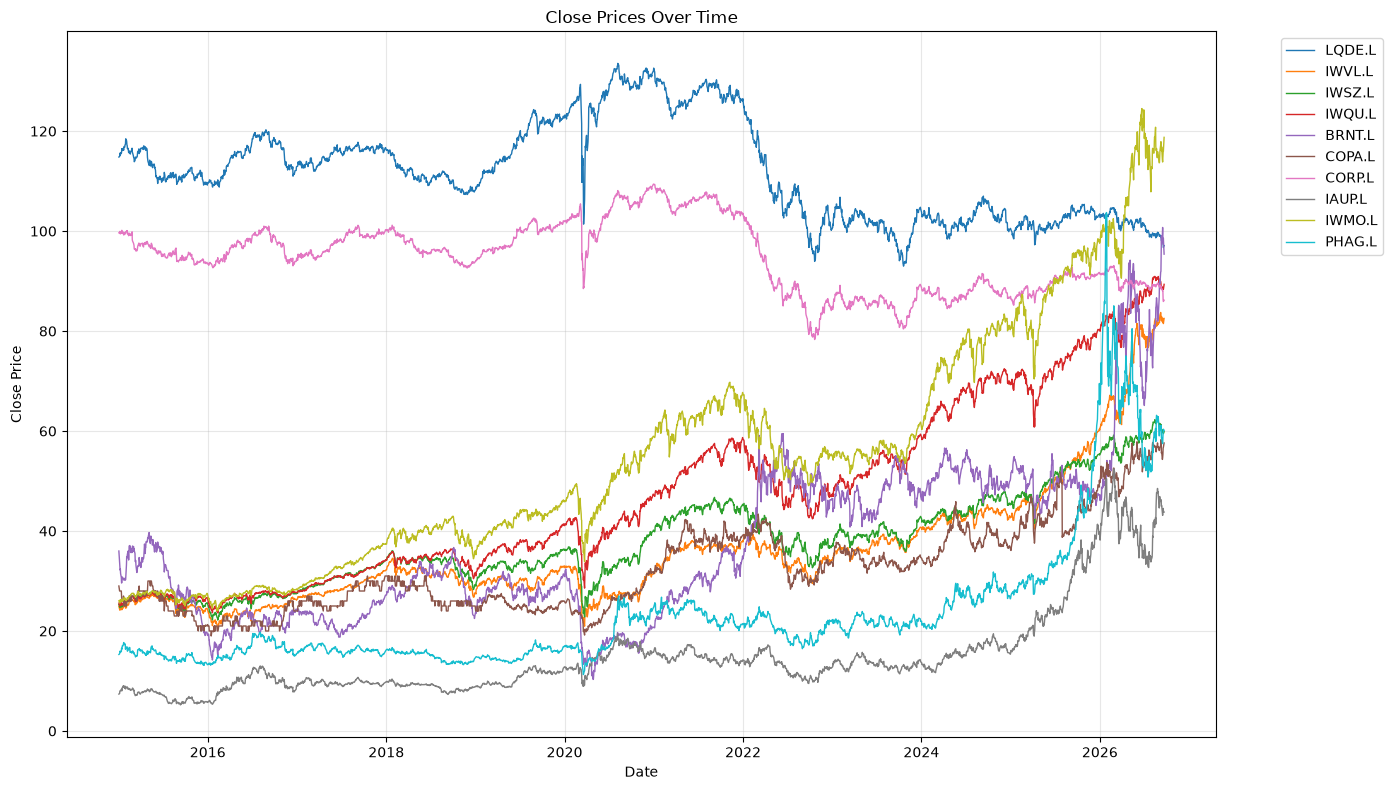

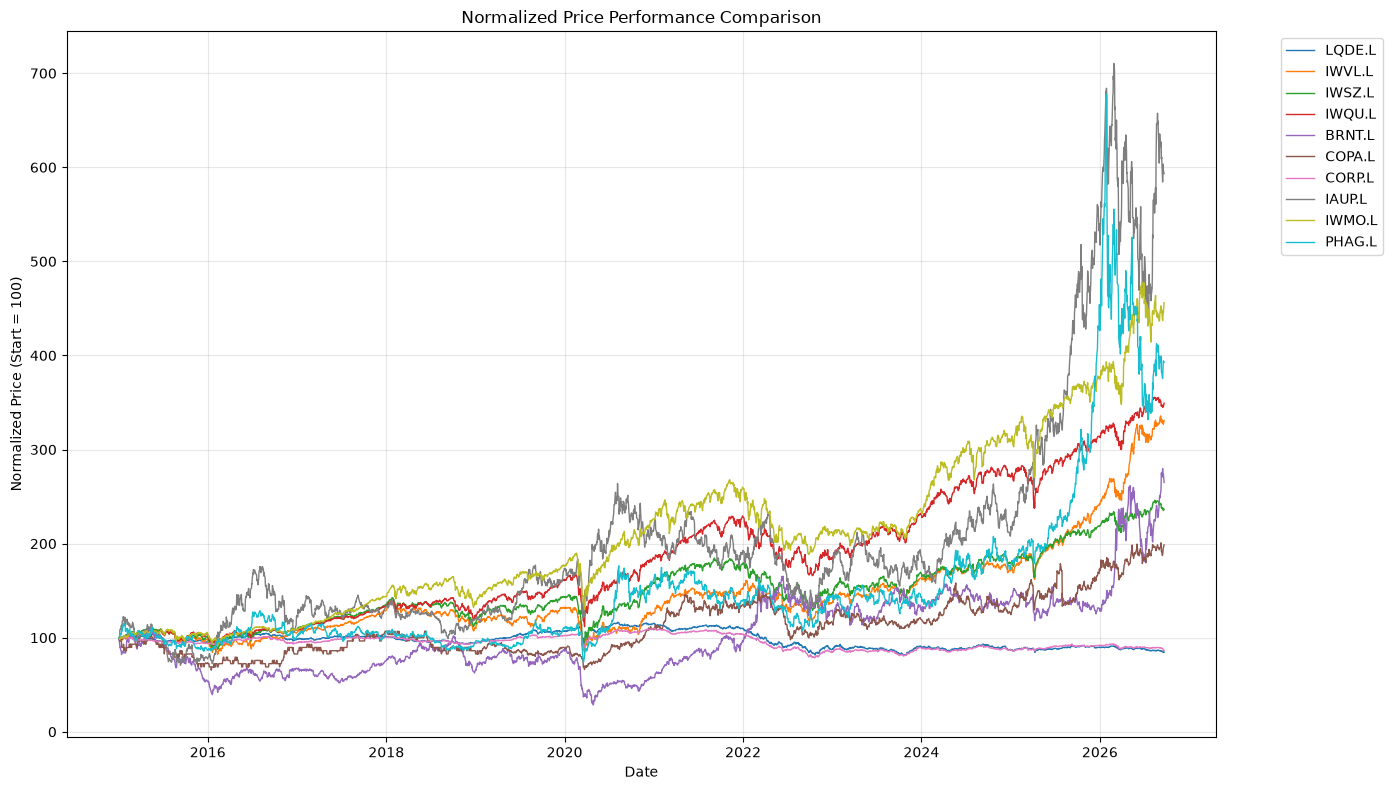

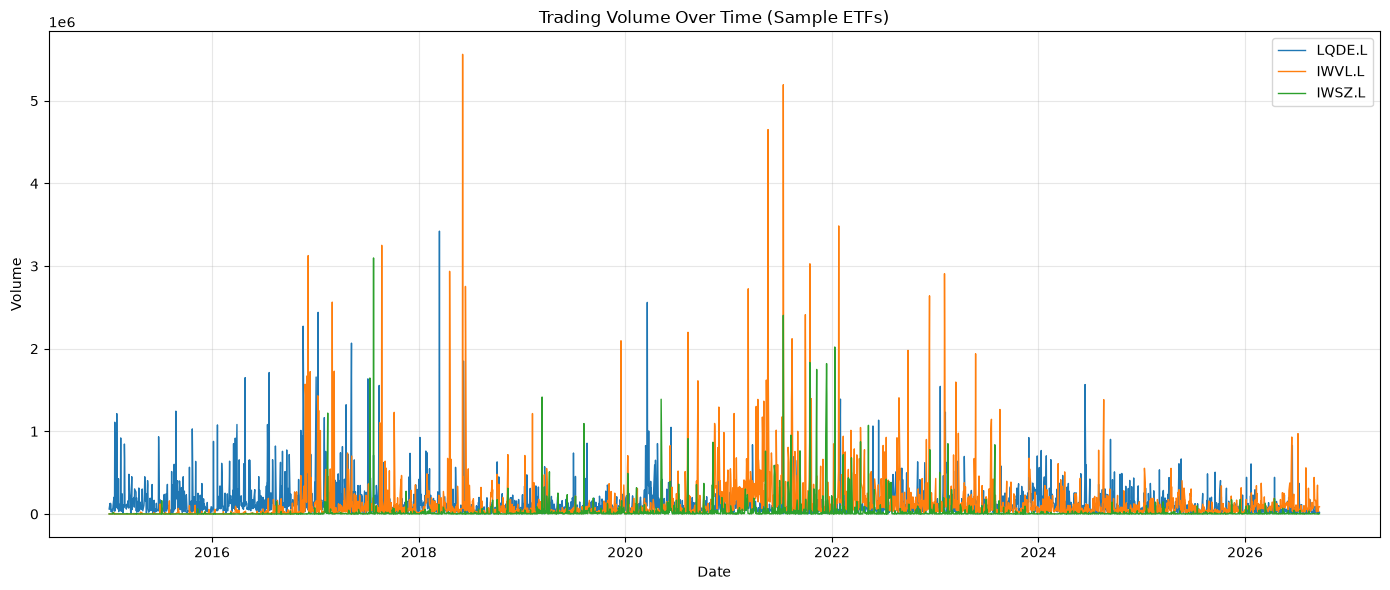


Sample ETF statistics:
LQDE.L: 2961 records from 2015-01-02 to 2026-09-21
  Price range: 92.99 - 133.55
  Avg volume: 128230
IWVL.L: 2961 records from 2015-01-02 to 2026-09-21
  Price range: 20.54 - 83.72
  Avg volume: 132573
IWSZ.L: 2961 records from 2015-01-02 to 2026-09-21
  Price range: 22.19 - 62.28
  Avg volume: 26373
IWQU.L: 2961 records from 2015-01-02 to 2026-09-21
  Price range: 23.62 - 90.94
  Avg volume: 59942
BRNT.L: 2961 records from 2015-01-02 to 2026-09-21
  Price range: 10.31 - 100.73
  Avg volume: 60319


In [8]:
# Section 7: Sample Time Series Visualization

from sqlalchemy import text, bindparam

try:
    # Load ETF universe to get representative samples
    from finance_analytics.universe.etfs import get_all_etfs
    etfs = get_all_etfs()
    
    # Define some representative ETFs we know should exist (from our universe)
    # These are examples - in practice we'd select based on what's actually in the database
    sample_tickers = []
    
    # Try to get a diverse sample: global equity, US equity, bond, commodity
    # We'll actually query what's available in the database
    with engine.connect() as conn:
        # Get top 10 ETFs by record count as our sample
        result = conn.execute(text("""
            SELECT ticker
            FROM prices
            GROUP BY ticker
            ORDER BY COUNT(*) DESC
            LIMIT 10
        """))
        sample_tickers = [row[0] for row in result.fetchall()]

except Exception as e:
    print(f"Could not load ETF universe: {e}")
    
    # Fallback to some common tickers if available
    sample_tickers = [
        'VWRP.L',
        'SWDA.L',
        'VHVG.L',
        'SWLD.L',
        'IMEU.L'
    ]


if sample_tickers:
    print(
        f"Visualizing time series for "
        f"{len(sample_tickers)} sample ETFs: {sample_tickers}"
    )

    # ---------------------------------------------------------
    # Fetch data for sample tickers
    # ---------------------------------------------------------
    with engine.connect() as conn:
        
        # Use SQLAlchemy's expanding parameter for the IN clause.
        # This safely expands :tickers into the required number
        # of parameters based on the length of sample_tickers.
        query = text("""
            SELECT date, ticker, open, high, low, close, volume
            FROM prices
            WHERE ticker IN :tickers
            ORDER BY ticker, date
        """).bindparams(
            bindparam("tickers", expanding=True)
        )

        df = pd.read_sql(
            query,
            conn,
            params={"tickers": sample_tickers}
        )

        df['date'] = pd.to_datetime(df['date'])

    # ---------------------------------------------------------
    # Check whether we actually got data
    # ---------------------------------------------------------
    if not df.empty:

        # -----------------------------------------------------
        # Plot 1: Close prices over time
        # -----------------------------------------------------
        plt.figure(figsize=(14, 8))

        for ticker in sample_tickers:
            ticker_data = (
                df[df['ticker'] == ticker]
                .sort_values('date')
            )

            if not ticker_data.empty:
                plt.plot(
                    ticker_data['date'],
                    ticker_data['close'],
                    label=ticker,
                    linewidth=1
                )

        plt.ylabel('Close Price')
        plt.xlabel('Date')
        plt.title('Close Prices Over Time')
        plt.legend(
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


        # -----------------------------------------------------
        # Plot 2: Normalized performance (starting at 100)
        # -----------------------------------------------------
        plt.figure(figsize=(14, 8))

        for ticker in sample_tickers:
            ticker_data = (
                df[df['ticker'] == ticker]
                .sort_values('date')
            )

            if not ticker_data.empty and len(ticker_data) > 1:
                # Normalize first close price to 100
                normalized = (
                    ticker_data['close']
                    / ticker_data['close'].iloc[0]
                ) * 100

                plt.plot(
                    ticker_data['date'],
                    normalized,
                    label=ticker,
                    linewidth=1
                )

        plt.ylabel('Normalized Price (Start = 100)')
        plt.xlabel('Date')
        plt.title('Normalized Price Performance Comparison')
        plt.legend(
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


        # -----------------------------------------------------
        # Plot 3: Volume over time
        # -----------------------------------------------------
        plt.figure(figsize=(14, 6))

        # Only show the first 3 tickers to avoid clutter
        volume_tickers = sample_tickers[
            :min(3, len(sample_tickers))
        ]

        for ticker in volume_tickers:
            ticker_data = (
                df[df['ticker'] == ticker]
                .sort_values('date')
            )

            if not ticker_data.empty:
                plt.plot(
                    ticker_data['date'],
                    ticker_data['volume'],
                    label=ticker,
                    linewidth=1
                )

        plt.ylabel('Volume')
        plt.xlabel('Date')
        plt.title('Trading Volume Over Time (Sample ETFs)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


        # -----------------------------------------------------
        # Show statistics
        # -----------------------------------------------------
        print("\nSample ETF statistics:")

        for ticker in sample_tickers[:5]:
            ticker_data = df[df['ticker'] == ticker]

            if not ticker_data.empty:
                print(
                    f"{ticker}: "
                    f"{len(ticker_data)} records from "
                    f"{ticker_data['date'].min().date()} "
                    f"to "
                    f"{ticker_data['date'].max().date()}"
                )

                print(
                    f"  Price range: "
                    f"{ticker_data['close'].min():.2f} - "
                    f"{ticker_data['close'].max():.2f}"
                )

                print(
                    f"  Avg volume: "
                    f"{ticker_data['volume'].mean():.0f}"
                )

            else:
                print(f"{ticker}: No data found")

    else:
        print("No price data found for the selected sample tickers.")

else:
    print("No sample tickers available for visualization.")


## Section 8: Returns Analysis

Verify we can calculate and visualize returns, which are fundamental to financial analysis.

Analyzing returns for 5 ETFs: ['IAUP.L', 'BRNT.L', 'CORP.L', 'COPA.L', 'IWMO.L']


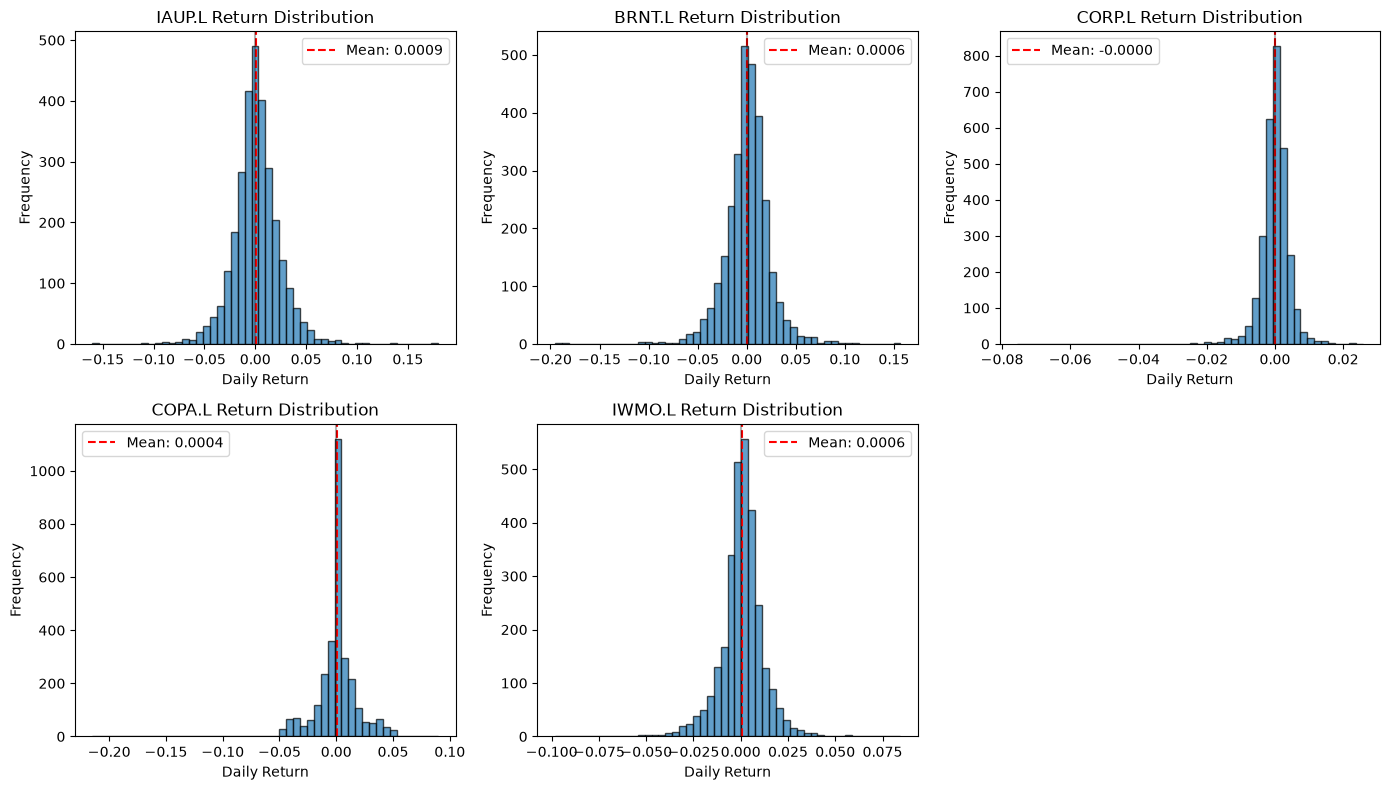

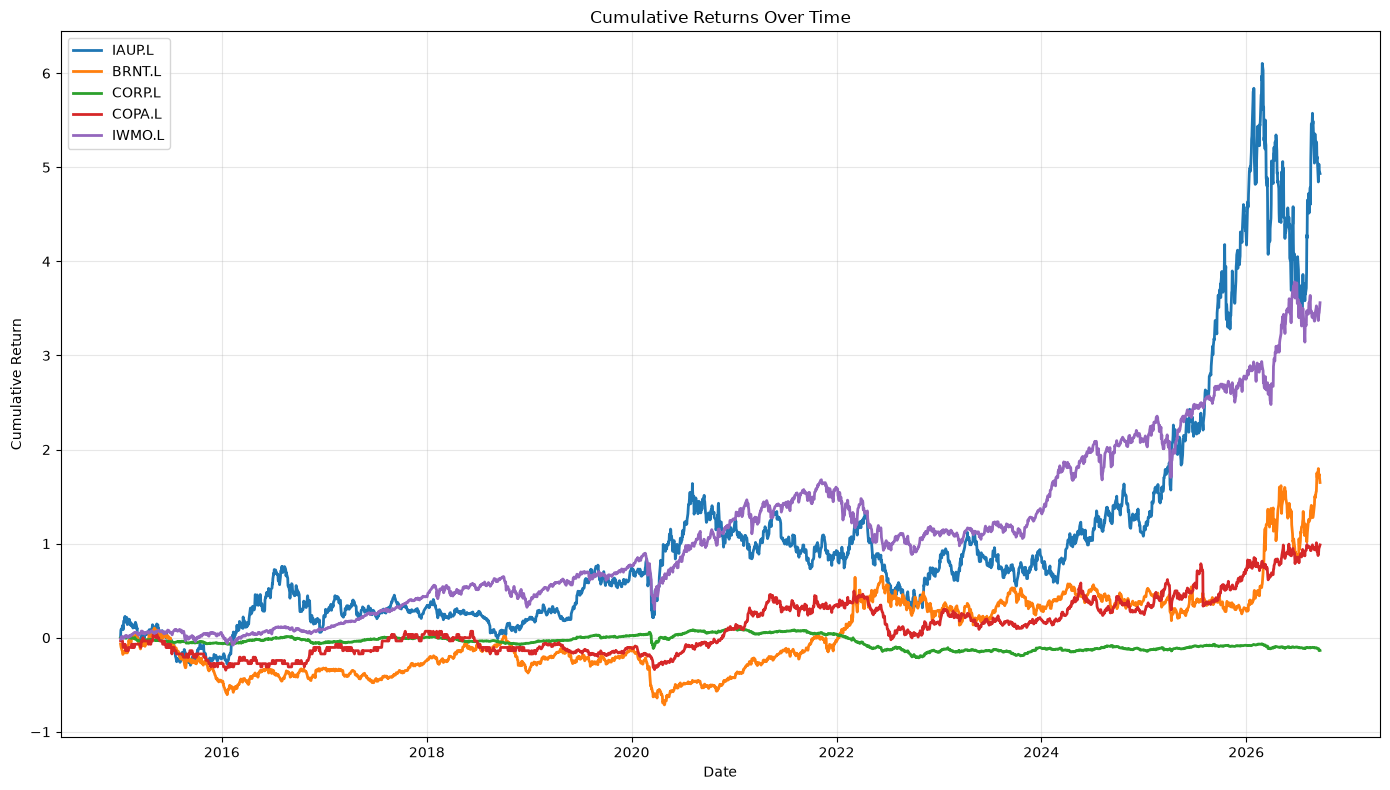

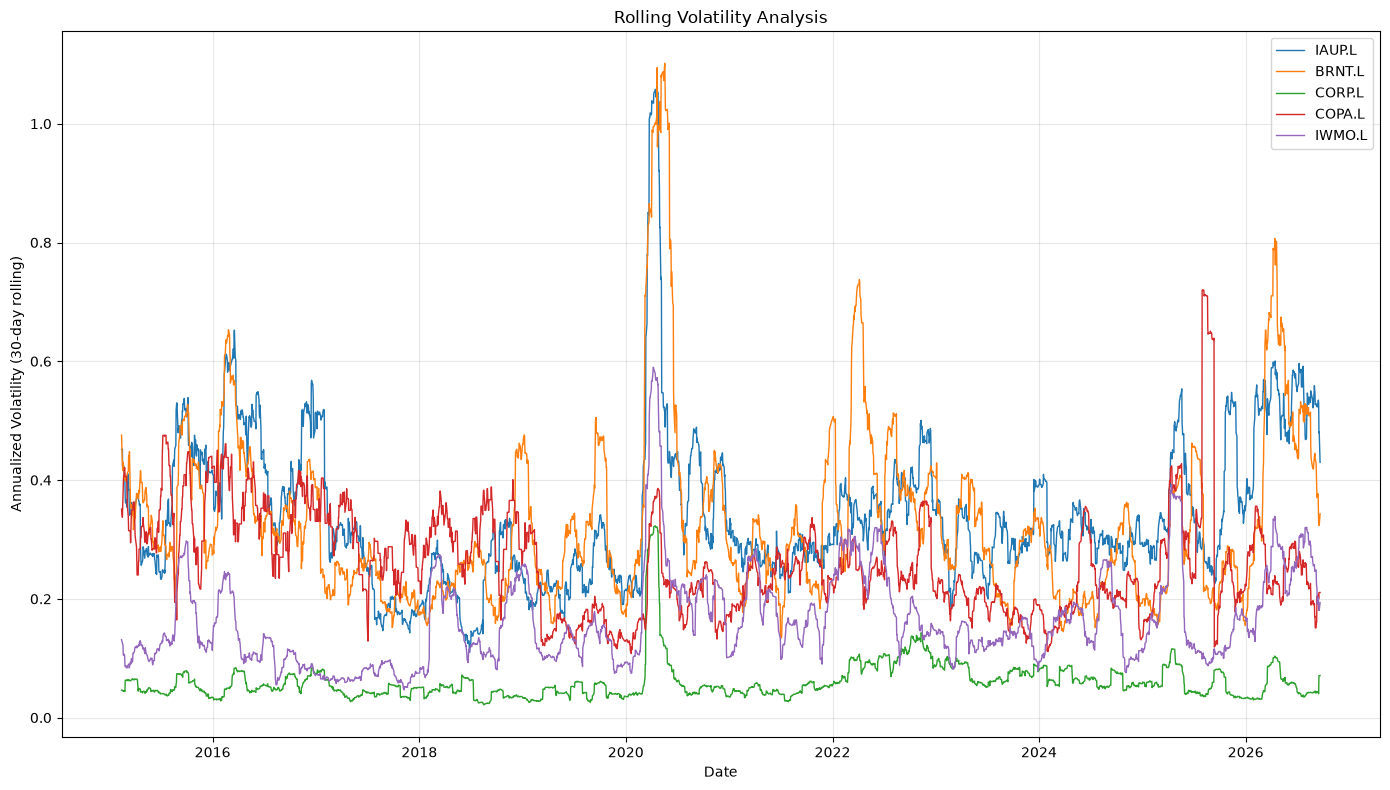


Returns Summary Statistics:
Ticker     Mean       Std        Skew       Kurtosis   Min        Max       
----------------------------------------------------------------------
IAUP.L     0.0009     0.0229     0.12       4.26       -0.16      0.18      
BRNT.L     0.0006     0.0228     -0.34      6.42       -0.20      0.16      
CORP.L     -0.0000    0.0044     -2.49      38.01      -0.08      0.03      
COPA.L     0.0004     0.0174     -0.62      9.57       -0.21      0.09      
IWMO.L     0.0006     0.0113     -0.40      5.60       -0.10      0.08      

Annualized Metrics (approx):
Ticker     Ann Return   Ann Volatility Sharpe (rf=0)
----------------------------------------------
IAUP.L     21.77%       36.37%       0.60        
BRNT.L     14.90%       36.22%       0.41        
CORP.L     -1.00%       6.93%        -0.14       
COPA.L     9.67%        27.55%       0.35        
IWMO.L     14.55%       18.01%       0.81        


In [10]:
# Section 8: Returns Analysis

from sqlalchemy import text, bindparam

try:
    # Get a few tickers for returns analysis (those with most data)
    with engine.connect() as conn:
        result = conn.execute(text("""
            SELECT ticker
            FROM prices
            GROUP BY ticker
            ORDER BY COUNT(*) DESC
            LIMIT 5
        """))
        return_tickers = [row[0] for row in result.fetchall()]

except Exception as e:
    print(f"Error getting tickers for returns analysis: {e}")
    return_tickers = []


if return_tickers:

    print(
        f"Analyzing returns for "
        f"{len(return_tickers)} ETFs: {return_tickers}"
    )

    # ---------------------------------------------------------
    # Fetch data for returns calculation
    # ---------------------------------------------------------
    with engine.connect() as conn:

        # Use SQLAlchemy's expanding parameter for the IN clause
        query = text("""
            SELECT date, ticker, close
            FROM prices
            WHERE ticker IN :tickers
            ORDER BY ticker, date
        """).bindparams(
            bindparam("tickers", expanding=True)
        )

        df_returns = pd.read_sql(
            query,
            conn,
            params={"tickers": return_tickers}
        )

        df_returns['date'] = pd.to_datetime(
            df_returns['date']
        )

    if not df_returns.empty:

        # -----------------------------------------------------
        # Calculate daily returns
        # -----------------------------------------------------
        df_returns['daily_return'] = (
            df_returns
            .groupby('ticker')['close']
            .pct_change()
        )

        # Remove first NaN return for each ticker
        df_returns_clean = (
            df_returns
            .dropna(subset=['daily_return'])
            .copy()
        )

        if not df_returns_clean.empty:

            # -------------------------------------------------
            # Plot 1: Return distributions
            # -------------------------------------------------
            plt.figure(figsize=(14, 8))

            for i, ticker in enumerate(return_tickers):

                plt.subplot(2, 3, i + 1)

                returns_data = (
                    df_returns_clean[
                        df_returns_clean['ticker'] == ticker
                    ]['daily_return']
                )

                if len(returns_data) > 0:

                    plt.hist(
                        returns_data,
                        bins=50,
                        alpha=0.7,
                        edgecolor='black'
                    )

                    plt.xlabel('Daily Return')
                    plt.ylabel('Frequency')
                    plt.title(
                        f'{ticker} Return Distribution'
                    )

                    # Mean return
                    plt.axvline(
                        returns_data.mean(),
                        color='red',
                        linestyle='--',
                        label=(
                            f'Mean: '
                            f'{returns_data.mean():.4f}'
                        )
                    )

                    # Zero-return reference line
                    plt.axvline(
                        0,
                        color='black',
                        linestyle='-',
                        alpha=0.3
                    )

                    plt.legend()

            plt.tight_layout()
            plt.show()


            # -------------------------------------------------
            # Plot 2: Cumulative returns
            # -------------------------------------------------
            plt.figure(figsize=(14, 8))

            for ticker in return_tickers:

                ticker_data = (
                    df_returns_clean[
                        df_returns_clean['ticker'] == ticker
                    ]
                    .sort_values('date')
                )

                if not ticker_data.empty:

                    # Calculate cumulative return:
                    # (1 + r1) * (1 + r2) * ... - 1
                    cumulative = (
                        1 + ticker_data['daily_return']
                    ).cumprod() - 1

                    plt.plot(
                        ticker_data['date'],
                        cumulative,
                        label=ticker,
                        linewidth=2
                    )

            plt.ylabel('Cumulative Return')
            plt.xlabel('Date')
            plt.title('Cumulative Returns Over Time')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


            # -------------------------------------------------
            # Plot 3: Rolling volatility (30-day)
            # -------------------------------------------------
            plt.figure(figsize=(14, 8))

            for ticker in return_tickers:

                ticker_data = (
                    df_returns_clean[
                        df_returns_clean['ticker'] == ticker
                    ]
                    .sort_values('date')
                )

                if len(ticker_data) >= 30:

                    # 30-day rolling volatility
                    # Annualized using sqrt(252)
                    rolling_vol = (
                        ticker_data['daily_return']
                        .rolling(window=30)
                        .std()
                        * np.sqrt(252)
                    )

                    plt.plot(
                        ticker_data['date'],
                        rolling_vol,
                        label=ticker,
                        linewidth=1
                    )

            plt.ylabel(
                'Annualized Volatility '
                '(30-day rolling)'
            )
            plt.xlabel('Date')
            plt.title('Rolling Volatility Analysis')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


            # -------------------------------------------------
            # Summary statistics table
            # -------------------------------------------------
            print("\nReturns Summary Statistics:")

            print(
                f"{'Ticker':<10} "
                f"{'Mean':<10} "
                f"{'Std':<10} "
                f"{'Skew':<10} "
                f"{'Kurtosis':<10} "
                f"{'Min':<10} "
                f"{'Max':<10}"
            )

            print("-" * 70)

            for ticker in return_tickers:

                returns_data = (
                    df_returns_clean[
                        df_returns_clean['ticker'] == ticker
                    ]['daily_return']
                )

                if len(returns_data) > 1:

                    mean_ret = returns_data.mean()
                    std_ret = returns_data.std()
                    skew_ret = returns_data.skew()
                    kurt_ret = returns_data.kurtosis()
                    min_ret = returns_data.min()
                    max_ret = returns_data.max()

                    print(
                        f"{ticker:<10} "
                        f"{mean_ret:<10.4f} "
                        f"{std_ret:<10.4f} "
                        f"{skew_ret:<10.2f} "
                        f"{kurt_ret:<10.2f} "
                        f"{min_ret:<10.2f} "
                        f"{max_ret:<10.2f}"
                    )

                else:

                    print(
                        f"{ticker:<10} "
                        f"{'Insufficient data':<10} "
                        f"{'':<10} "
                        f"{'':<10} "
                        f"{'':<10} "
                        f"{'':<10} "
                        f"{'':<10}"
                    )


            # -------------------------------------------------
            # Annualized return and volatility
            # -------------------------------------------------
            print("\nAnnualized Metrics (approx):")

            print(
                f"{'Ticker':<10} "
                f"{'Ann Return':<12} "
                f"{'Ann Volatility':<12} "
                f"{'Sharpe (rf=0)':<12}"
            )

            print("-" * 46)

            for ticker in return_tickers:

                returns_data = (
                    df_returns_clean[
                        df_returns_clean['ticker'] == ticker
                    ]['daily_return']
                )

                if len(returns_data) > 1:

                    # Approximate annualized arithmetic return
                    ann_return = (
                        returns_data.mean() * 252
                    )

                    # Annualized volatility
                    ann_vol = (
                        returns_data.std() * np.sqrt(252)
                    )

                    # Sharpe ratio assuming 0% risk-free rate
                    sharpe = (
                        ann_return / ann_vol
                        if ann_vol != 0
                        else 0
                    )

                    print(
                        f"{ticker:<10} "
                        f"{ann_return:<12.2%} "
                        f"{ann_vol:<12.2%} "
                        f"{sharpe:<12.2f}"
                    )

                else:

                    print(
                        f"{ticker:<10} "
                        f"{'Insufficient':<12} "
                        f"{'data':<12} "
                        f"{'':<12}"
                    )

        else:

            print(
                "Insufficient data for returns calculation "
                "(need at least 2 observations per ticker)."
            )

    else:

        print("No data found for returns analysis.")

else:

    print("No tickers available for returns analysis.")


## Section 9: Correlation Analysis

Examine relationships between ETFs by analyzing correlations in their returns.

Analyzing correlations for 15 ETFs with sufficient data: ['LQDE.L', 'PHAG.L', 'IWQU.L', 'IWVL.L', 'PHAU.L', 'COPA.L', 'CORP.L', 'IWMO.L', 'IAUP.L', 'IWSZ.L', 'BRNT.L', 'SJPA.L', 'SLXX.L', 'GLRE.L', 'SWDA.L']


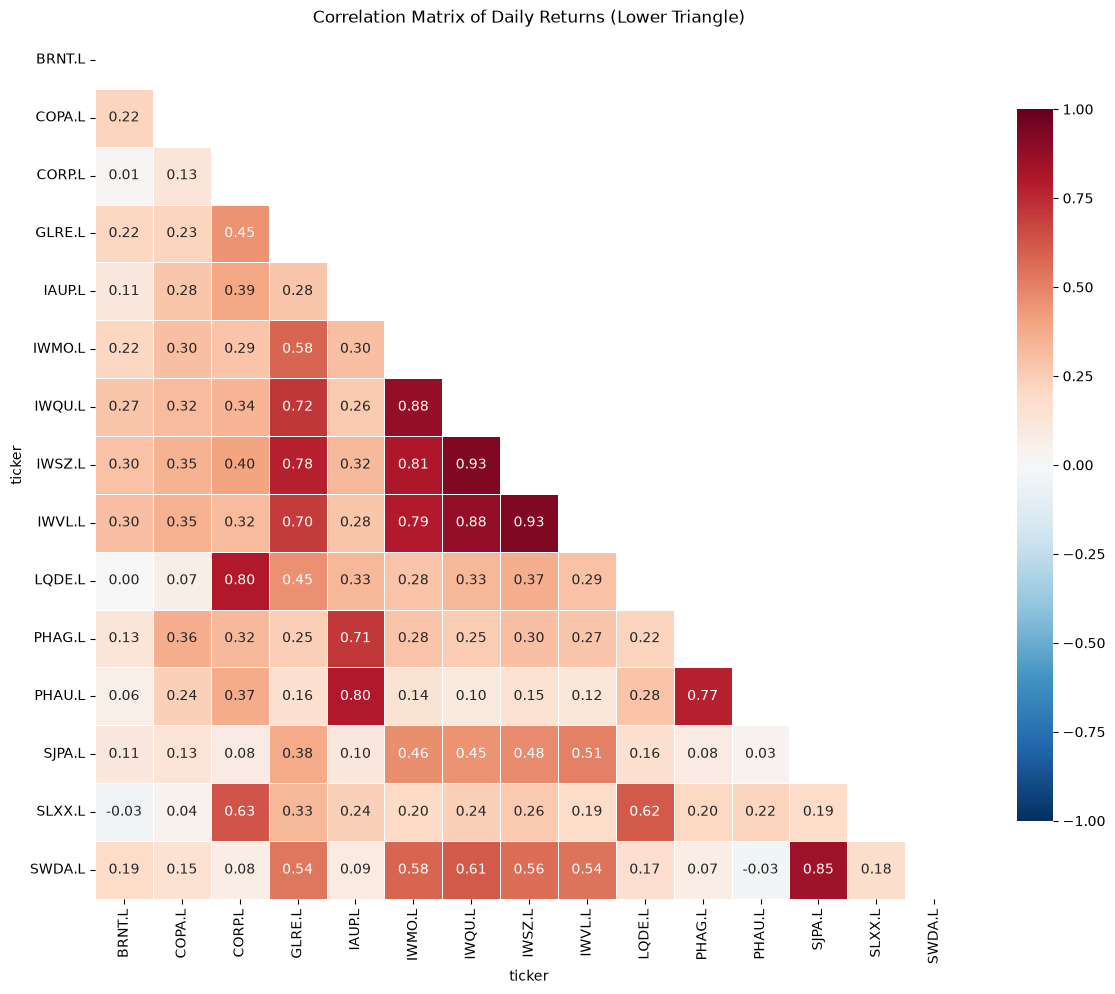

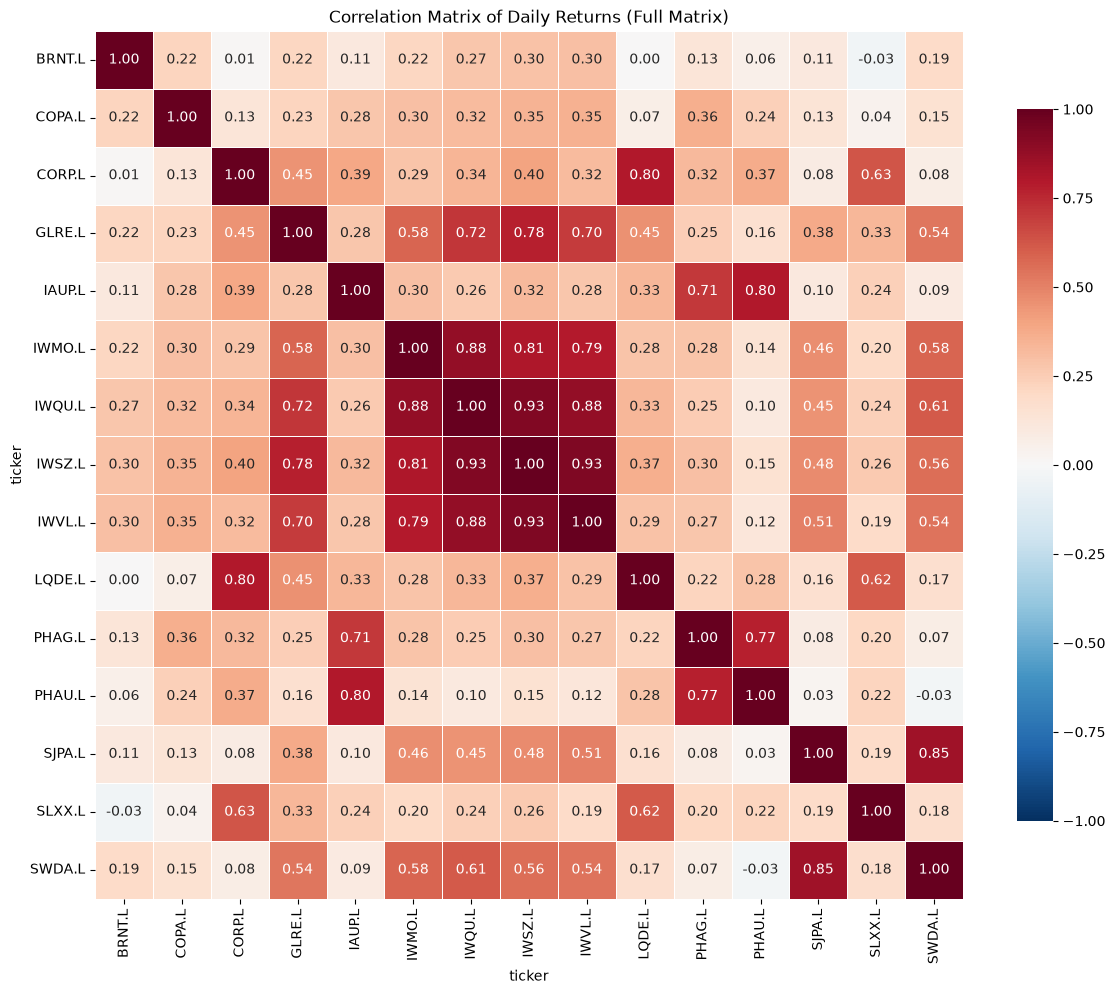


Highly Correlated Pairs (|correlation| > 0.7):
  IWSZ.L - IWVL.L: 0.930
  IWQU.L - IWSZ.L: 0.927
  IWMO.L - IWQU.L: 0.879
  IWQU.L - IWVL.L: 0.878
  SJPA.L - SWDA.L: 0.846
  IWMO.L - IWSZ.L: 0.806
  CORP.L - LQDE.L: 0.804
  IAUP.L - PHAU.L: 0.800
  IWMO.L - IWVL.L: 0.794
  GLRE.L - IWSZ.L: 0.776
  PHAG.L - PHAU.L: 0.773
  GLRE.L - IWQU.L: 0.718
  IAUP.L - PHAG.L: 0.707

Least Correlated Pairs (closest to 0):
  BRNT.L - LQDE.L: 0.004
  BRNT.L - CORP.L: 0.009
  PHAU.L - SJPA.L: 0.026
  PHAU.L - SWDA.L: -0.030
  BRNT.L - SLXX.L: -0.033

Correlation Statistics:
  Mean correlation: 0.336
  Median correlation: 0.283
  Std correlation: 0.236
  Min correlation: -0.033
  Max correlation: 0.930


In [12]:
# Section 9: Correlation Analysis

from sqlalchemy import text, bindparam

try:
    # Get tickers with sufficient data for correlation analysis
    with engine.connect() as conn:
        # Get tickers with at least 100 observations
        # (enough for meaningful correlation analysis)
        result = conn.execute(text("""
            SELECT ticker
            FROM prices
            GROUP BY ticker
            HAVING COUNT(*) >= 100
            ORDER BY COUNT(*) DESC
            LIMIT 15
        """))

        corr_tickers = [row[0] for row in result.fetchall()]

except Exception as e:
    print(
        f"Error getting tickers for correlation analysis: {e}"
    )
    corr_tickers = []


if corr_tickers and len(corr_tickers) >= 2:

    print(
        f"Analyzing correlations for "
        f"{len(corr_tickers)} ETFs with sufficient data: "
        f"{corr_tickers}"
    )

    # ---------------------------------------------------------
    # Fetch data for correlation calculation
    # ---------------------------------------------------------
    with engine.connect() as conn:

        # Use SQLAlchemy's expanding parameter for the IN clause
        query = text("""
            SELECT date, ticker, close
            FROM prices
            WHERE ticker IN :tickers
            ORDER BY date, ticker
        """).bindparams(
            bindparam("tickers", expanding=True)
        )

        df_corr = pd.read_sql(
            query,
            conn,
            params={"tickers": corr_tickers}
        )

        df_corr['date'] = pd.to_datetime(
            df_corr['date']
        )


    if not df_corr.empty:

        # -----------------------------------------------------
        # Pivot prices into a date x ticker matrix
        # -----------------------------------------------------
        df_pivot = df_corr.pivot(
            index='date',
            columns='ticker',
            values='close'
        )

        # -----------------------------------------------------
        # Calculate daily returns
        # -----------------------------------------------------
        df_returns = df_pivot.pct_change()

        # Remove dates where there are no returns at all
        df_returns = df_returns.dropna(
            how='all'
        )

        # Remove tickers with fewer than 2 valid returns
        # to avoid meaningless correlations
        valid_columns = (
            df_returns.count() >= 2
        )

        df_returns = df_returns.loc[
            :,
            valid_columns
        ]

        if (
            not df_returns.empty
            and df_returns.shape[1] >= 2
        ):

            # -------------------------------------------------
            # Calculate correlation matrix
            # -------------------------------------------------
            corr_matrix = df_returns.corr(
                min_periods=2
            )

            # Remove any completely invalid rows/columns
            corr_matrix = corr_matrix.dropna(
                axis=0,
                how='all'
            ).dropna(
                axis=1,
                how='all'
            )

            if corr_matrix.shape[1] >= 2:

                # -------------------------------------------------
                # Plot 1: Correlation heatmap
                # -------------------------------------------------
                plt.figure(figsize=(12, 10))

                # Hide upper triangle
                mask = np.triu(
                    np.ones_like(
                        corr_matrix,
                        dtype=bool
                    )
                )

                sns.heatmap(
                    corr_matrix,
                    mask=mask,
                    annot=True,
                    fmt='.2f',
                    cmap='RdBu_r',
                    center=0,
                    vmin=-1,
                    vmax=1,
                    square=True,
                    linewidths=0.5,
                    cbar_kws={
                        "shrink": 0.8
                    }
                )

                plt.title(
                    'Correlation Matrix of Daily Returns '
                    '(Lower Triangle)'
                )

                plt.tight_layout()
                plt.show()


                # -------------------------------------------------
                # Plot 2: Full correlation matrix
                # -------------------------------------------------
                plt.figure(figsize=(12, 10))

                sns.heatmap(
                    corr_matrix,
                    annot=True,
                    fmt='.2f',
                    cmap='RdBu_r',
                    center=0,
                    vmin=-1,
                    vmax=1,
                    square=True,
                    linewidths=0.5,
                    cbar_kws={
                        "shrink": 0.8
                    }
                )

                plt.title(
                    'Correlation Matrix of Daily Returns '
                    '(Full Matrix)'
                )

                plt.tight_layout()
                plt.show()


                # -------------------------------------------------
                # Find highly correlated pairs
                # -------------------------------------------------
                print(
                    "\nHighly Correlated Pairs "
                    "(|correlation| > 0.7):"
                )

                high_corr_pairs = []

                for i in range(
                    len(corr_matrix.columns)
                ):
                    for j in range(
                        i + 1,
                        len(corr_matrix.columns)
                    ):

                        ticker1 = (
                            corr_matrix.columns[i]
                        )

                        ticker2 = (
                            corr_matrix.columns[j]
                        )

                        corr_val = (
                            corr_matrix.iloc[i, j]
                        )

                        if pd.notna(corr_val) and abs(
                            corr_val
                        ) > 0.7:

                            high_corr_pairs.append(
                                (
                                    ticker1,
                                    ticker2,
                                    corr_val
                                )
                            )

                if high_corr_pairs:

                    for (
                        ticker1,
                        ticker2,
                        corr_val
                    ) in sorted(
                        high_corr_pairs,
                        key=lambda x: abs(x[2]),
                        reverse=True
                    ):

                        print(
                            f"  {ticker1} - {ticker2}: "
                            f"{corr_val:.3f}"
                        )

                else:

                    print(
                        "  No pairs with correlation "
                        "> 0.7 found."
                    )


                # -------------------------------------------------
                # Find least correlated pairs
                # -------------------------------------------------
                print(
                    "\nLeast Correlated Pairs "
                    "(closest to 0):"
                )

                low_corr_pairs = []

                for i in range(
                    len(corr_matrix.columns)
                ):
                    for j in range(
                        i + 1,
                        len(corr_matrix.columns)
                    ):

                        ticker1 = (
                            corr_matrix.columns[i]
                        )

                        ticker2 = (
                            corr_matrix.columns[j]
                        )

                        corr_val = (
                            corr_matrix.iloc[i, j]
                        )

                        if pd.notna(corr_val):

                            # Store the actual correlation
                            # as well as its absolute value
                            low_corr_pairs.append(
                                (
                                    ticker1,
                                    ticker2,
                                    corr_val,
                                    abs(corr_val)
                                )
                            )

                # Sort by absolute correlation,
                # so values closest to zero appear first
                low_corr_pairs.sort(
                    key=lambda x: x[3]
                )

                for (
                    ticker1,
                    ticker2,
                    corr_val,
                    abs_corr
                ) in low_corr_pairs[:5]:

                    print(
                        f"  {ticker1} - {ticker2}: "
                        f"{corr_val:.3f}"
                    )


                # -------------------------------------------------
                # Show correlation statistics
                # -------------------------------------------------
                print(
                    "\nCorrelation Statistics:"
                )

                # Get unique pairwise correlations
                # from the upper triangle
                upper_triu = []

                for i in range(
                    len(corr_matrix.columns)
                ):
                    for j in range(
                        i + 1,
                        len(corr_matrix.columns)
                    ):

                        corr_val = (
                            corr_matrix.iloc[i, j]
                        )

                        if pd.notna(corr_val):
                            upper_triu.append(
                                corr_val
                            )

                if upper_triu:

                    print(
                        f"  Mean correlation: "
                        f"{np.mean(upper_triu):.3f}"
                    )

                    print(
                        f"  Median correlation: "
                        f"{np.median(upper_triu):.3f}"
                    )

                    print(
                        f"  Std correlation: "
                        f"{np.std(upper_triu):.3f}"
                    )

                    print(
                        f"  Min correlation: "
                        f"{np.min(upper_triu):.3f}"
                    )

                    print(
                        f"  Max correlation: "
                        f"{np.max(upper_triu):.3f}"
                    )

                else:

                    print(
                        "  No correlation pairs "
                        "to analyze."
                    )

            else:

                print(
                    "Insufficient valid correlation "
                    "data after cleaning."
                )

        else:

            print(
                "Insufficient returns data for "
                "correlation analysis."
            )

    else:

        print(
            "No data found for correlation analysis."
        )

else:

    print(
        "Need at least 2 tickers with sufficient data "
        "(>=100 observations) for correlation analysis."
    )

## Section 10: Incremental Update Verification

Confirm that the incremental update mechanism in update_database.py is working correctly.

In [13]:
# Section 10: Incremental Update Verification

with engine.connect() as conn:
    # Check the most recent dates in the database
    result = conn.execute(text("""
        SELECT ticker, MAX(date) as latest_date
        FROM prices
        GROUP BY ticker
        ORDER BY latest_date DESC
    """))
    latest_dates = result.fetchall()

if latest_dates:
    today = pd.Timestamp.now().date()
    print(f"\nLatest data dates in database (as of {today}):")
    print("=" * 50)

    # Calculate how recent the data is
    days_behind = []
    for ticker, latest_date in latest_dates:
        if isinstance(latest_date, pd.Timestamp):
            latest_date = latest_date.date()
        days_diff = (today - latest_date).days
        days_behind.append(days_diff)
        print(f"{ticker:<10}: {latest_date} ({days_diff} days behind)")

    if days_behind:
        avg_days_behind = np.mean(days_behind)
        median_days_behind = np.median(days_behind)
        max_days_behind = np.max(days_behind)
        print(f"\nRecency Statistics:")
        print(f"  Average days behind: {avg_days_behind:.1f}")
        print(f"  Median days behind: {median_days_behind:.1f}")
        print(f"  Maximum days behind: {max_days_behind}")

        # Check if data is reasonably current (should be within a few days for active markets)
        recent_count = sum(1 for d in days_behind if d <= 2)  # Within 2 trading days
        print(f"\nETFs with data within 2 days: {recent_count} out of {len(latest_dates)}")

        if avg_days_behind <= 3:
            print("✓ Data appears to be reasonably current.")
        else:
            print("⚠ Data may be stale - consider running update_database.py.")
    else:
        print("No date data available.")

    # Show what would be downloaded on next run (simplified)
    print(f"\nNext Update Preview:")
    print("The update_database.py script would:")
    print("1. Find the earliest missing date across all tickers")
    print("2. Download data from that date to today")
    print("3. Insert only new records (avoiding duplicates via UPSERT)")

    # Show earliest date that needs updating
    earliest_latest = min([date for _, date in latest_dates])
    if isinstance(earliest_latest, pd.Timestamp):
        earliest_latest = earliest_latest.date()
    next_start = earliest_latest + pd.Timedelta(days=1)
    print(f"\nNext update would start from: {next_start}")
    print(f"(This is the day after the earliest ticker's latest date)")

else:
    print("No data found in prices table.")



Latest data dates in database (as of 2026-09-24):
XDWE.L    : 2026-09-21 (3 days behind)
AGGU.L    : 2026-09-21 (3 days behind)
BRNT.L    : 2026-09-21 (3 days behind)
CBU0.L    : 2026-09-21 (3 days behind)
CNDX.L    : 2026-09-21 (3 days behind)
CNYA.L    : 2026-09-21 (3 days behind)
COPA.L    : 2026-09-21 (3 days behind)
CORP.L    : 2026-09-21 (3 days behind)
CPXJ.L    : 2026-09-21 (3 days behind)
CSPX.L    : 2026-09-21 (3 days behind)
CSUK.L    : 2026-09-21 (3 days behind)
CUKX.L    : 2026-09-21 (3 days behind)
EMIM.L    : 2026-09-21 (3 days behind)
GHYS.L    : 2026-09-21 (3 days behind)
GLRE.L    : 2026-09-21 (3 days behind)
IAUP.L    : 2026-09-21 (3 days behind)
IBTS.L    : 2026-09-21 (3 days behind)
IDTG.L    : 2026-09-21 (3 days behind)
IEQU.L    : 2026-09-21 (3 days behind)
IIND.L    : 2026-09-21 (3 days behind)
IKOR.L    : 2026-09-21 (3 days behind)
IMEU.L    : 2026-09-21 (3 days behind)
INFR.L    : 2026-09-21 (3 days behind)
IUCD.L    : 2026-09-21 (3 days behind)
IUCM.L    : 2

## Section 11: Data Export Capability

Demonstrate how to extract data from the database for further analysis, backtesting, or reporting.

In [14]:
# Section 11: Data Export Capability

print("This section shows how to extract data from the database for external use.")

# Example 1: Extract complete dataset for a specific ticker
print("\n=== Example 1: Extract data for a single ticker ===")
try:
    with engine.connect() as conn:
        # Get a ticker with good data
        result = conn.execute(text("""
            SELECT ticker
            FROM prices
            GROUP BY ticker
            ORDER BY COUNT(*) DESC
            LIMIT 1
        """))
        sample_ticker = result.fetchone()
        if sample_ticker:
            sample_ticker = sample_ticker[0]
            print(f"Selected ticker: {sample_ticker}")
            
            # Extract all data for this ticker
            query = """
                SELECT date, open, high, low, close, volume
                FROM prices
                WHERE ticker = %s
                ORDER BY date
            """
            df_ticker = pd.read_sql(text(query), conn, params=[sample_ticker])
            df_ticker['date'] = pd.to_datetime(df_ticker['date'])
            
            print(f"Extracted {len(df_ticker)} rows for {sample_ticker}")
            print(f"Date range: {df_ticker['date'].min().date()} to {df_ticker['date'].max().date()}")
            print(f"Columns: {list(df_ticker.columns)}")
            
            # Show how to save to CSV
            csv_filename = f"{sample_ticker}_price_data.csv"
            print(f"\nTo save to CSV: df_ticker.to_csv('{csv_filename}', index=False)")
            
            # Show how to save to pickle (preserves data types)
            pkl_filename = f"{sample_ticker}_price_data.pkl"
            print(f"To save to pickle: df_ticker.to_pickle('{pkl_filename}')")
            
            # Calculate returns as example of further processing
            df_ticker['daily_return'] = df_ticker['close'].pct_change()
            print(f"\nExample calculation - daily returns for {sample_ticker}:")
            print(f"  Mean daily return: {df_ticker['daily_return'].mean():.4f}")
            print(f"  Annualized return (approx): {df_ticker['daily_return'].mean() * 252:.2%}")
            print(f"  Annualized volatility (approx): {df_ticker['daily_return'].std() * np.sqrt(252):.2%}")
        else:
            print("No data found in prices table.")
except Exception as e:
    print(f"Error in Example 1: {e}")

# Example 2: Extract data for multiple tickers for comparison
print("\n\n=== Example 2: Extract data for multiple tickers ===")
try:
    with engine.connect() as conn:
        # Get top 3 tickers by data completeness
        result = conn.execute(text("""
            SELECT ticker, COUNT(*) as record_count
            FROM prices
            GROUP BY ticker
            ORDER BY record_count DESC
            LIMIT 3
        """))
        top_tickers = [row[0] for row in result.fetchall()]
        
        if top_tickers:
            print(f"Selected tickers: {top_tickers}")
            
            # Extract data for all selected tickers
            placeholders = ','.join(['%s'] * len(top_tickers))
            query = f"""
                SELECT date, ticker, close
                FROM prices
                WHERE ticker IN ({placeholders})
                ORDER BY date, ticker
            """
            df_multi = pd.read_sql(text(query), conn, params=top_tickers)
            df_multi['date'] = pd.to_datetime(df_multi['date'])
            
            print(f"Extracted {len(df_multi)} rows total")
            
            # Pivot for easy comparison
            df_pivot = df_multi.pivot(index='date', columns='ticker', values='close')
            print(f"Pivoted data shape: {df_pivot.shape} ({len(df_pivot)} dates x {len(df_pivot.columns)} tickers)")
            
            # Calculate correlation matrix
            returns_pivot = df_pivot.pct_change().dropna()
            if not returns_pivot.empty:
                corr_matrix = returns_pivot.corr()
                print(f"Correlation matrix calculated: {corr_matrix.shape}")
                print(f"Average correlation: {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean():.3f}")
            
            # Show how to save
            print(f"\nTo save pivoted data: df_pivot.to_pickle('multi_ticker_prices.pkl')")
            print(f"To save returns: returns_pivot.to_pickle('multi_ticker_returns.pkl')")
        else:
            print("No data found in prices table.")
except Exception as e:
    print(f"Error in Example 2: {e}")

# Example 3: Extract data for a specific date range
print("\n\n=== Example 3: Extract data for a date range ===")
try:
    with engine.connect() as conn:
        # Get overall date range
        result = conn.execute(text("""
            SELECT MIN(date) as min_date, MAX(date) as max_date
            FROM prices
        """))
        date_bounds = result.fetchone()
        
        if date_bounds and date_bounds[0] and date_bounds[1]:
            min_date, max_date = date_bounds
            if isinstance(min_date, pd.Timestamp):
                min_date = min_date.date()
    if isinstance(max_date, pd.Timestamp):
        max_date = max_date.date()
    
    print(f"Overall data range: {min_date} to {max_date}")
    
    # Extract last 6 months of data (or less if we don't have that much)
    end_date = max_date
    start_date = max(min_date, end_date - pd.Timedelta(days=6*30))  # Approx 6 months
    
    print(f"Extracting data from {start_date} to {end_date} (last ~6 months)")
    
    # Get a few tickers for this example
    result = conn.execute(text("""
        SELECT ticker
        FROM prices
        GROUP BY ticker
        ORDER BY COUNT(*) DESC
        LIMIT 3
    """))
    example_tickers = [row[0] for row in result.fetchall()]
    
    if example_tickers:
        placeholders = ','.join(['%s'] * len(example_tickers))
        query = f"""
            SELECT date, ticker, open, high, low, close, volume
            FROM prices
            WHERE ticker IN ({placeholders})
              AND date >= %s
              AND date <= %s
            ORDER BY ticker, date
        """
        df_range = pd.read_sql(text(query), conn, params=example_tickers + [start_date, end_date])
        df_range['date'] = pd.to_datetime(df_range['date'])
        
        print(f"Extracted {len(df_range)} rows for {len(example_tickers)} tickers")
        print(f"Date range in extract: {df_range['date'].min().date()} to {df_range['date'].max().date()}")
        
        # Show how to save
        print(f"\nTo save this extract: df_range.to_pickle('recent_6m_data.pkl')")
        
        # Example visualization of this extract
        if len(df_range) > 0:
            plt.figure(figsize=(12, 6))
            for ticker in example_tickers:
                ticker_data = df_range[df_range['ticker'] == ticker].sort_values('date')
                if not ticker_data.empty:
                    # Normalize to first value = 100 for comparison
                    normalized = (ticker_data['close'] / ticker_data['close'].iloc[0]) * 100
                    plt.plot(ticker_data['date'], normalized, label=ticker, linewidth=2)
            plt.ylabel('Normalized Price (Start = 100)')
            plt.xlabel('Date')
            plt.title(f'Price Performance: {start_date} to {end_date}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
    else:
        print("No date bounds found or no data in prices table.")
except Exception as e:
    print(f"Error in Example 3: {e}")

print("\n\n=== Summary ===")
print("This notebook demonstrated:")
print("1. Database connectivity and schema verification")
print("2. Data overview and coverage analysis")
print("3. Data quality checks (OHLC relationships)")
print("4. Time series visualization capabilities")
print("5. Returns analysis and risk metrics")
print("6. Correlation analysis between ETFs")
print("7. Incremental update verification")
print("8. Data export capabilities for external analysis")
print("\nYou can use these patterns as a starting point for your own analysis and reporting.")


This section shows how to extract data from the database for external use.

=== Example 1: Extract data for a single ticker ===
Selected ticker: BRNT.L
Error in Example 1: Execution failed on sql '
                SELECT date, open, high, low, close, volume
                FROM prices
                WHERE ticker = %s
                ORDER BY date
            ': List argument must consist only of dictionaries


=== Example 2: Extract data for multiple tickers ===
Selected tickers: ['COPA.L', 'BRNT.L', 'CORP.L']
Error in Example 2: Execution failed on sql '
                SELECT date, ticker, close
                FROM prices
                WHERE ticker IN (%s,%s,%s)
                ORDER BY date, ticker
            ': List argument must consist only of dictionaries


=== Example 3: Extract data for a date range ===
Overall data range: 2015-01-02 to 2026-09-21
Extracting data from 2026-03-25 to 2026-09-21 (last ~6 months)
Error in Example 3: This Connection is closed


=== Summary ===